# Project 2 - Image Classification Networks

## 0. Import Packages

Load relevant python packages

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import copy
import time
import os
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading & Preprocessing

### 1.1 Preprocessing Function

The steps are:
1. Convert the raw numpy array to a PyTorch tensor on the correct device and dtype
2. **Normalise**: - CIFAR-10's data will be normalised by using its known *mean* and *standard deviation*, note we will use the values in 0-255 scale. (The values used were taken from ["How to calculate the mean and standard deviation - Normalizing datasets in Pytorch."](#references))
3. **Permute** from `NHWC` (NumPy/PIL format) to `NCHW` (PyTorch conv format)

In [2]:
def preprocess_data(data, device, dtype):
    # Convert numpy array to tensor on the target device and dtype (float16 on GPU, float32 on CPU)
    data = torch.tensor(data, device=device).to(dtype)

    # Normalise using CIFAR-10 per-channel mean and std (values in 0-255 scale)
    mean = torch.tensor([125.31, 122.95, 113.87], device=device).to(dtype)
    std  = torch.tensor([62.99,  62.09,  66.70],  device=device).to(dtype)
    data = (data - mean) / std

    # Permute from NHWC → NCHW (required by PyTorch Conv2d)
    data = data.permute(0, 3, 1, 2)

    return data

### 1.2 Load CIFAR-10
A key difference from a standard CIFAR-10 setup:

- The official **train set (50,000)** and **test set (10,000)** are combined into one pool of 60,000 images
- This pool is then split **80/20** → 48,000 training / 12,000 validation
- Training images are **padded from 32×32 to 40×40** using reflection padding, this is done once upfront so that random 32×32 crops can be taken cheaply inside the training loop later

In [3]:
def load_cifar10(device, dtype, data_dir='./data'):
    # Download train and test sets (labels only — no transforms applied here)
    train_set = torchvision.datasets.CIFAR10(root=data_dir, train=True,  download=True)
    test_set  = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True)

    # Combine all 60,000 images and labels into one pool
    all_data    = np.concatenate([train_set.data, test_set.data], axis=0)
    all_targets = train_set.targets + test_set.targets

    # 80/20 split → 48,000 train / 12,000 validation
    split = int(0.8 * len(all_data))

    train_data  = preprocess_data(all_data[:split], device, dtype)
    valid_data  = preprocess_data(all_data[split:], device, dtype)

    train_targets = torch.tensor(all_targets[:split]).to(device)
    valid_targets = torch.tensor(all_targets[split:]).to(device)

    # Pad training images from 32×32 → 40×40 using reflection padding
    # This allows random 32×32 crops during training (data augmentation)
    train_data = nn.ReflectionPad2d(4)(train_data)

    return train_data, train_targets, valid_data, valid_targets

### 1.3 Device & dtype Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float16 if device.type != "cpu" else torch.float32

print(f"Device : {torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'}")
print(f"Dtype  : {dtype}")

# Load data
train_data, train_targets, valid_data, valid_targets = load_cifar10(device, dtype)

print(f"\nTrain data shape    : {train_data.shape}")   
print(f"Valid data shape    : {valid_data.shape}")     
print(f"Train targets shape : {train_targets.shape}")
print(f"Valid targets shape : {valid_targets.shape}")

## 2. Data Augmentation

### 2.1 Inline Augmentation (random crop + flip)

These two augmentations are applied **every epoch** inside the training loop on the full training set at once, making them very efficient.

**Random Crop**
Training images were padded to 40×40 earlier. Each epoch, a random 32×32 region is cropped from each image. This teaches the network that objects can appear at different positions in the image — effectively multiplying the dataset size by the number of possible crop positions.

**Horizontal Flip**
The first half of each shuffled batch is flipped horizontally. Since CIFAR-10 classes (cars, dogs, planes etc.) are equally likely to face either direction, a horizontally flipped image is just as valid a training example as the original.

In [86]:
def random_crop(data, crop_size=(32, 32)):
    crop_h, crop_w = crop_size
    h = data.size(2)
    w = data.size(3)

    # Pick a random top-left corner for the crop
    x = torch.randint(w - crop_w, size=(1,))[0]
    y = torch.randint(h - crop_h, size=(1,))[0]

    return data[:, :, y : y + crop_h, x : x + crop_w]

## 3. Model Architecture

### 3.1 Ghost Batch Normalisation

In [87]:
class GhostBatchNorm(nn.BatchNorm2d):
    def __init__(self, num_features, num_splits, **kw):
        super().__init__(num_features, **kw)

        # Running stats are stored separately for each ghost sub-batch
        running_mean = torch.zeros(num_features * num_splits)
        running_var  = torch.ones(num_features * num_splits)

        # Affine parameters (scale/bias) are shared across all splits
        self.weight.requires_grad = False
        self.num_splits = num_splits
        self.register_buffer("running_mean", running_mean)
        self.register_buffer("running_var",  running_var)

    def train(self, mode=True):
        if (self.training is True) and (mode is False):
            # When switching to eval mode, collapse per-split stats into one
            # by averaging across all ghost sub-batches
            self.running_mean = torch.mean(
                self.running_mean.view(self.num_splits, self.num_features), dim=0
            ).repeat(self.num_splits)
            self.running_var = torch.mean(
                self.running_var.view(self.num_splits, self.num_features), dim=0
            ).repeat(self.num_splits)
        return super().train(mode)

    def forward(self, input):
        n, c, h, w = input.shape
        if self.training or not self.track_running_stats:
            # During training: reshape to treat each split as its own mini-batch
            assert n % self.num_splits == 0, \
                f"Batch size ({n}) must be divisible by num_splits ({self.num_splits})"
            return F.batch_norm(
                input.view(-1, c * self.num_splits, h, w),
                self.running_mean,
                self.running_var,
                self.weight.repeat(self.num_splits),
                self.bias.repeat(self.num_splits),
                True,
                self.momentum,
                self.eps,
            ).view(n, c, h, w)
        else:
            # During eval: use the averaged running stats from the first split
            return F.batch_norm(
                input,
                self.running_mean[: self.num_features],
                self.running_var[: self.num_features],
                self.weight,
                self.bias,
                False,
                self.momentum,
                self.eps,
            )

### 3.2 Building Blocks (conv_bn_relu, conv_pool_norm_act)

In [88]:
def conv_bn_relu(c_in, c_out, kernel_size=(3, 3), padding=(1, 1)):
    # Feature refinement block — spatial size unchanged
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=kernel_size, padding=padding, bias=False),
        GhostBatchNorm(c_out, num_splits=16),
        nn.CELU(alpha=0.3),
    )


def conv_pool_norm_act(c_in, c_out):
    # Downsampling block — spatial size halved by MaxPool
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=(3, 3), padding=(1, 1), bias=False),
        nn.MaxPool2d(kernel_size=2, stride=2),
        GhostBatchNorm(c_out, num_splits=16),
        nn.CELU(alpha=0.3),
    )

### 3.3 ResNetBagOfTricks

In [89]:
class ResNetBagOfTricks(nn.Module):
    def __init__(self, c_in, c_out, scale_out):
        super().__init__()

        # Standard trainable first conv layer (no frozen whitening weights)
        self.conv1   = nn.Conv2d(c_in, 64, kernel_size=(3, 3), padding=(1, 1), bias=False)
        self.conv2   = conv_bn_relu(64, 64, kernel_size=(1, 1), padding=0)   # 1×1 channel projection
        self.conv3   = conv_pool_norm_act(64, 128)                            # 32×32 → 16×16
        self.conv4   = conv_bn_relu(128, 128)                                 # residual branch
        self.conv5   = conv_bn_relu(128, 128)                                 # residual branch
        self.conv6   = conv_pool_norm_act(128, 256)                           # 16×16 → 8×8
        self.conv7   = conv_pool_norm_act(256, 512)                           # 8×8   → 4×4
        self.conv8   = conv_bn_relu(512, 512)                                 # residual branch
        self.conv9   = conv_bn_relu(512, 512)                                 # residual branch
        self.pool10  = nn.MaxPool2d(kernel_size=4, stride=4)                  # 4×4   → 1×1
        self.linear11 = nn.Linear(512, c_out, bias=False)
        self.scale_out = scale_out

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x + self.conv5(self.conv4(x))   # First residual connection
        x = self.conv6(x)
        x = self.conv7(x)
        x = x + self.conv9(self.conv8(x))   # Second residual connection
        x = self.pool10(x)
        x = x.reshape(x.size(0), x.size(1)) # Flatten (N, 512, 1, 1) → (N, 512)
        x = self.linear11(x)
        x = self.scale_out * x              # Scale down logits for training stability
        return x

We now instantiate the model, convert it to the appropriate dtype, and move it to the device. Note that **BatchNorm layers are kept in float32** even when the rest of the model is in float16 — this is because BN's running statistics are sensitive to the reduced precision of float16 and can produce unstable or inaccurate normalisation if downcast.

In [90]:
net = ResNetBagOfTricks(c_in=3, c_out=10, scale_out=0.125)

# Convert all weights to float16 (or float32 on CPU)
net.to(dtype)

# Revert BatchNorm layers back to float32 for numerical stability
for module in net.modules():
    if isinstance(module, nn.BatchNorm2d):
        module.float()

# Move model to device
net.to(device)

# Count trainable parameters
trainable = sum(p.numel() for p in net.parameters() if p.requires_grad)
total     = sum(p.numel() for p in net.parameters())
print(f"Trainable parameters : {trainable:,}")
print(f"Total parameters     : {total:,}")

Trainable parameters : 6,574,976
Total parameters     : 6,577,216


## 4. Loss Function — Label Smoothing

In [91]:
def label_smoothing_loss(inputs, targets, alpha):
    # Compute log-softmax over class dimension
    log_probs = F.log_softmax(inputs, dim=1)

    # KL divergence term — pushes predictions toward uniform distribution
    # This is equivalent to the mean of log-probs across all classes
    kl = -log_probs.mean(dim=1)

    # Standard cross-entropy term — pushes correct class probability up
    xent = F.nll_loss(log_probs, targets, reduction="none")

    # Weighted combination of both terms
    # alpha=0.2 means 80% cross-entropy, 20% smoothing toward uniform
    loss = (1 - alpha) * xent + alpha * kl

    return loss

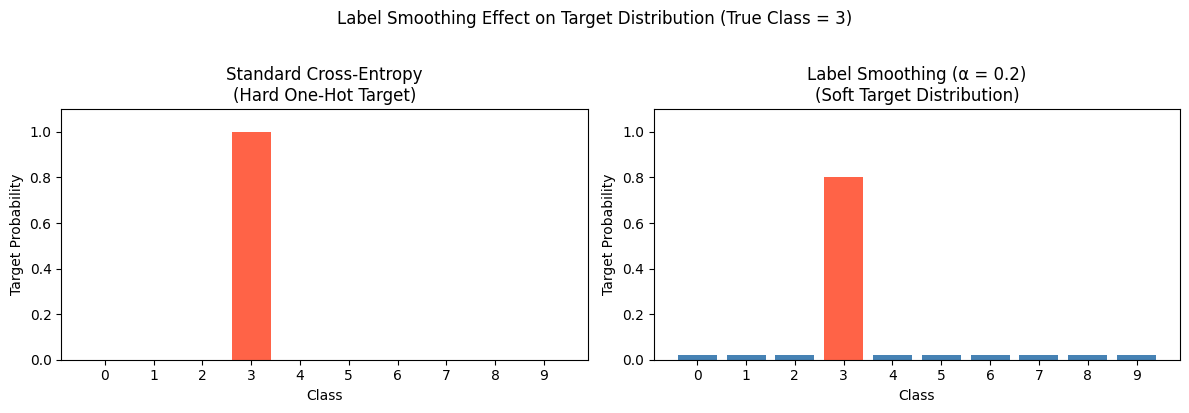

In [92]:
import matplotlib.pyplot as plt
import numpy as np

alpha      = 0.2
n_classes  = 10
true_class = 3

# Standard one-hot target
hard_target = np.zeros(n_classes)
hard_target[true_class] = 1.0

# Label smoothing soft target
soft_target = np.full(n_classes, alpha / n_classes)
soft_target[true_class] = 1 - alpha

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors_hard = ['tomato' if i == true_class else 'steelblue' for i in range(n_classes)]
colors_soft = ['tomato' if i == true_class else 'steelblue' for i in range(n_classes)]

ax1.bar(range(n_classes), hard_target, color=colors_hard)
ax1.set_title('Standard Cross-Entropy\n(Hard One-Hot Target)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Target Probability')
ax1.set_xticks(range(n_classes))
ax1.set_ylim(0, 1.1)

ax2.bar(range(n_classes), soft_target, color=colors_soft)
ax2.set_title(f'Label Smoothing (α = {alpha})\n(Soft Target Distribution)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Target Probability')
ax2.set_xticks(range(n_classes))
ax2.set_ylim(0, 1.1)

plt.suptitle('Label Smoothing Effect on Target Distribution (True Class = 3)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Training Strategy

### 5.1 Learning Rate Schedule

In [93]:
# Two-phase linear learning rate schedule defined over batches
lr_schedule = torch.cat([
    torch.linspace(0e+0, 2e-3, 194),   # Phase 1: warmup  0 → 0.002
    torch.linspace(2e-3, 2e-4, 582),   # Phase 2: decay   0.002 → 0.0002
])

# Biases use a 64x scaled version of the same schedule
lr_schedule_bias = 64.0 * lr_schedule

We can visualise both schedules across all batches to see the warmup and decay phases clearly.

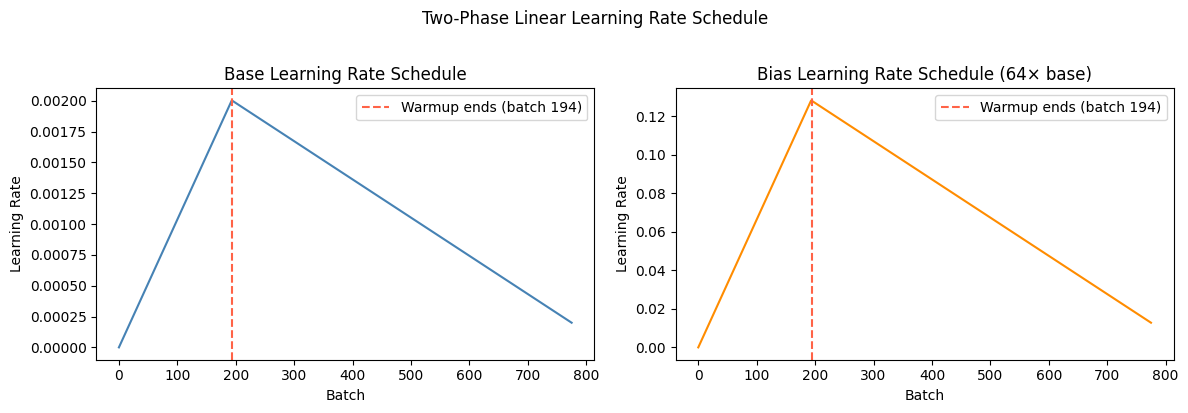

In [94]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

batches = range(len(lr_schedule))

ax1.plot(batches, lr_schedule.numpy(), color='steelblue')
ax1.axvline(x=194, color='tomato', linestyle='--', label='Warmup ends (batch 194)')
ax1.set_title('Base Learning Rate Schedule')
ax1.set_xlabel('Batch')
ax1.set_ylabel('Learning Rate')
ax1.legend()

ax2.plot(batches, lr_schedule_bias.numpy(), color='darkorange')
ax2.axvline(x=194, color='tomato', linestyle='--', label='Warmup ends (batch 194)')
ax2.set_title('Bias Learning Rate Schedule (64× base)')
ax2.set_xlabel('Batch')
ax2.set_ylabel('Learning Rate')
ax2.legend()

plt.suptitle('Two-Phase Linear Learning Rate Schedule', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Nesterov SGD (manual)


In [95]:
def update_nesterov(weights, lr, weight_decay, momentum):
    for weight, velocity in weights:
        if weight.requires_grad:
            gradient = weight.grad.data
            weight   = weight.data

            # Add L2 weight decay to gradient, then scale by learning rate
            gradient.add_(weight, alpha=weight_decay).mul_(-lr)

            # Update velocity with momentum
            velocity.mul_(momentum).add_(gradient)

            # Nesterov update: apply gradient + momentum-corrected velocity
            weight.add_(gradient.add_(velocity, alpha=momentum))

In [96]:
# Separate weights (conv/linear kernels) from biases (1D parameters)
weights = [
    (w, torch.zeros_like(w))
    for w in net.parameters()
    if w.requires_grad and len(w.shape) > 1
]

biases = [
    (w, torch.zeros_like(w))
    for w in net.parameters()
    if w.requires_grad and len(w.shape) <= 1
]

print(f"Weight tensors : {len(weights)}")
print(f"Bias tensors   : {len(biases)}")

Weight tensors : 10
Bias tensors   : 8


### 5.3 Exponential Moving Average (EMA)

In [97]:
# Hyperparameters
momentum        = 0.9
weight_decay    = 0.256
weight_decay_bias = 0.004
ema_update_freq = 5
ema_rho         = 0.99 ** ema_update_freq   # ≈ 0.951

def update_ema(train_model, valid_model, rho):
    train_weights = train_model.state_dict().values()
    valid_weights = valid_model.state_dict().values()

    for train_weight, valid_weight in zip(train_weights, valid_weights):
        if valid_weight.dtype in [torch.float16, torch.float32]:
            # Decay the EMA model's weights toward the training model's weights
            valid_weight *= rho
            valid_weight += (1 - rho) * train_weight

# Create EMA validation model as a deep copy of the training model
valid_net = copy.deepcopy(net)

print(f"EMA decay (rho)      : {ema_rho:.4f}")
print(f"EMA update frequency : every {ema_update_freq} batches")

EMA decay (rho)      : 0.9510
EMA update frequency : every 5 batches


## 6. Training Loop

In [98]:
# Training configuration
epochs     = 10
batch_size = 512

# Tracking metrics across epochs
history = {
    'train_loss' : [],
    'val_acc'    : [],
    'train_time' : [],
}

print("epoch    batch    train time [sec]    validation accuracy")
print("-" * 65)

train_time  = 0.0
batch_count = 0

for epoch in range(1, epochs + 1):

    # ------------------------------------------------------------------ #
    #  PHASE 1 — Shuffle & Augment                                        #
    # ------------------------------------------------------------------ #

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    # Randomly shuffle all training data
    indices = torch.randperm(len(train_data), device=device)
    data    = train_data[indices]
    targets = train_targets[indices]

    # Apply random 32×32 crop to every image in the shuffled dataset
    # Each batch gets its own random crop position
    data = [
        random_crop(data[i : i + batch_size], crop_size=(32, 32))
        for i in range(0, len(data), batch_size)
    ]
    data = torch.cat(data)

    # Randomly flip the first half of the training data horizontally
    data[: len(data) // 2] = torch.flip(data[: len(data) // 2], [-1])

    # ------------------------------------------------------------------ #
    #  PHASE 2 — Train                                                    #
    # ------------------------------------------------------------------ #

    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, len(data), batch_size):

        # Discard partial final batch (GhostBatchNorm requires exact splits)
        if i + batch_size > len(data):
            break

        inputs = data[i : i + batch_size]
        target = targets[i : i + batch_size]
        batch_count += 1

        # Forward pass
        net.zero_grad()
        net.train(True)

        logits = net(inputs)
        loss   = label_smoothing_loss(logits, target, alpha=0.2)
        loss.sum().backward()

        # Look up current learning rate from schedule
        lr_index = min(batch_count, len(lr_schedule) - 1)
        lr       = lr_schedule[lr_index]
        lr_bias  = lr_schedule_bias[lr_index]

        # Update weights and biases using manual Nesterov SGD
        update_nesterov(weights, lr, weight_decay, momentum)
        update_nesterov(biases,  lr_bias, weight_decay_bias, momentum)

        # Update EMA validation model every ema_update_freq batches
        if (i // batch_size % ema_update_freq) == 0:
            update_ema(net, valid_net, ema_rho)

        epoch_loss  += loss.sum().item()
        num_batches += 1

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # Record training time for this epoch
    train_time += time.perf_counter() - start_time
    avg_loss    = epoch_loss / num_batches
    history['train_loss'].append(avg_loss)
    history['train_time'].append(train_time)

    # ------------------------------------------------------------------ #
    #  PHASE 3 — Validate (EMA model + TTA)                              #
    # ------------------------------------------------------------------ #

    valid_correct = []

    for i in range(0, len(valid_data), batch_size):
        valid_net.train(False)

        # Test-Time Augmentation: evaluate on original and horizontally flipped inputs
        regular_inputs = valid_data[i : i + batch_size]
        flipped_inputs = torch.flip(regular_inputs, [-1])

        logits1 = valid_net(regular_inputs).detach()
        logits2 = valid_net(flipped_inputs).detach()

        # Average logits from both augmentations for final prediction
        logits = torch.mean(torch.stack([logits1, logits2], dim=0), dim=0)

        # Check which predictions are correct
        correct = logits.max(dim=1)[1] == valid_targets[i : i + batch_size]
        valid_correct.append(correct.detach().type(torch.float64))

    # Validation accuracy is the mean number of correct predictions
    val_acc = torch.mean(torch.cat(valid_correct)).item()
    history['val_acc'].append(val_acc)

    print(f"{epoch:5}    {batch_count:6}    {train_time:18.2f}    {val_acc:22.4f}")

print("-" * 65)
print(f"\nFinal Validation Accuracy : {max(history['val_acc']):.4f}")
print(f"Total Training Time       : {train_time:.2f} seconds")

epoch    batch    train time [sec]    validation accuracy
-----------------------------------------------------------------
    1        93                 10.47                    0.1814
    2       186                 20.26                    0.6482
    3       279                 30.03                    0.8252
    4       372                 39.38                    0.8710
    5       465                 48.85                    0.8905
    6       558                 58.38                    0.9057
    7       651                 68.11                    0.9187
    8       744                 77.72                    0.9268
    9       837                 87.35                    0.9327
   10       930                 97.09                    0.9366
-----------------------------------------------------------------

Final Validation Accuracy : 0.9366
Total Training Time       : 97.09 seconds


## 7. Results & Analysis

### 7.1 Accuracy & Loss Curves

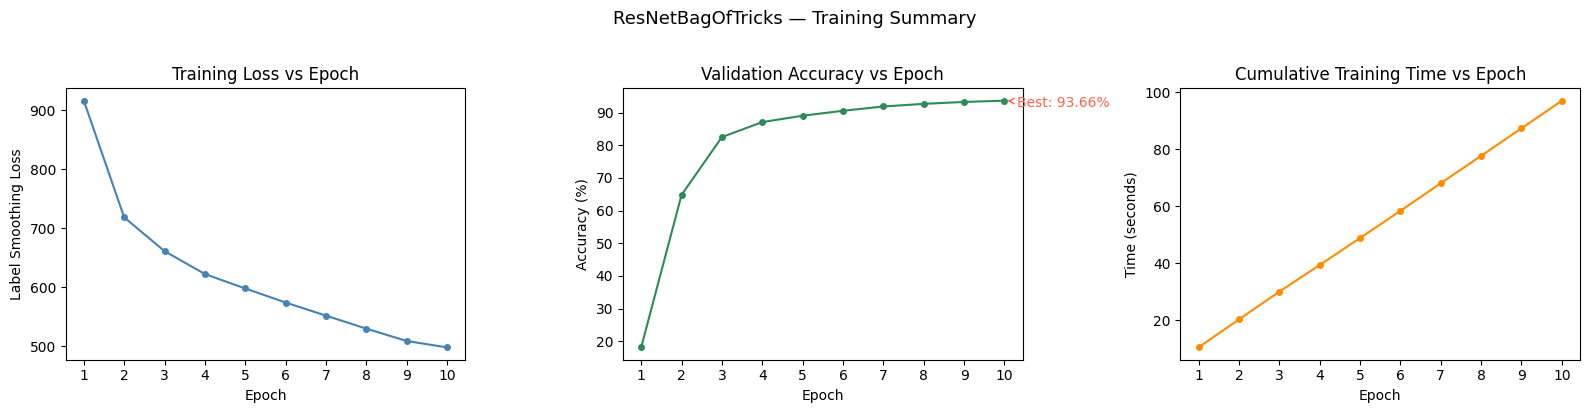

In [99]:
epochs_range = range(1, epochs + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# --- Loss Curve ---
ax1.plot(epochs_range, history['train_loss'], color='steelblue', marker='o', markersize=4)
ax1.set_title('Training Loss vs Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Label Smoothing Loss')
ax1.set_xticks(epochs_range)

# --- Validation Accuracy Curve ---
ax2.plot(epochs_range, [acc * 100 for acc in history['val_acc']], color='seagreen', marker='o', markersize=4)
ax2.set_title('Validation Accuracy vs Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)

# Annotate best accuracy
best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
best_acc   = max(history['val_acc']) * 100
ax2.annotate(
    f'Best: {best_acc:.2f}%',
    xy=(best_epoch, best_acc),
    xytext=(best_epoch + 0.3, best_acc - 2),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato'
)

# --- Cumulative Training Time ---
ax3.plot(epochs_range, history['train_time'], color='darkorange', marker='o', markersize=4)
ax3.set_title('Cumulative Training Time vs Epoch')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Time (seconds)')
ax3.set_xticks(epochs_range)

plt.suptitle('ResNetBagOfTricks — Training Summary', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

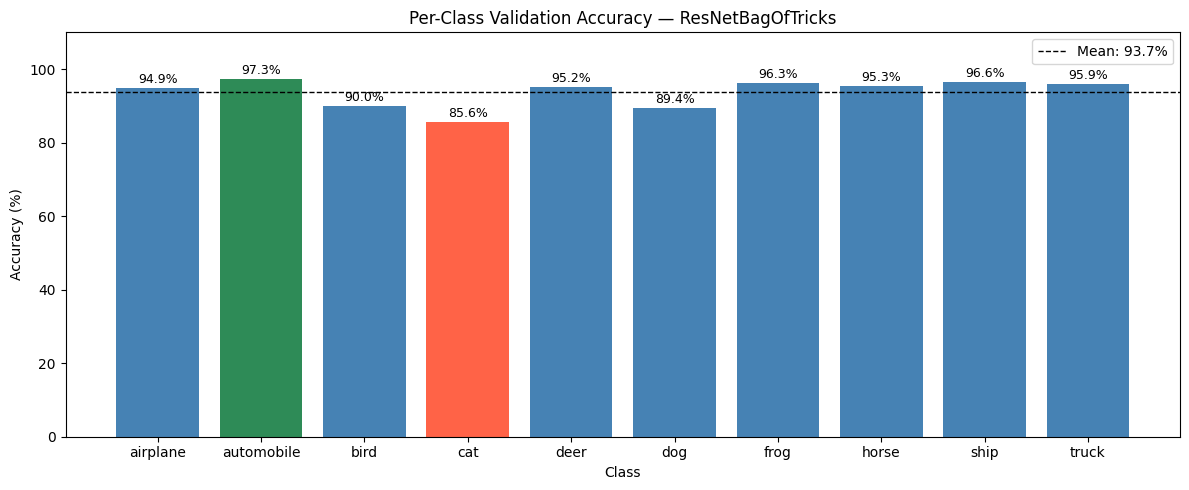

Class         Correct    Total   Accuracy
------------------------------------------
airplane         1136     1197     94.90%
automobile       1170     1202     97.34%
bird             1068     1187     89.97%
cat              1039     1214     85.58%
deer             1116     1172     95.22%
dog              1071     1198     89.40%
frog             1160     1204     96.35%
horse            1145     1201     95.34%
ship             1174     1215     96.63%
truck            1160     1210     95.87%
------------------------------------------
Overall         11239    12000     93.66%


In [100]:
# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Collect per-class predictions from the final EMA model
class_correct = torch.zeros(10)
class_total   = torch.zeros(10)

valid_net.train(False)

with torch.no_grad():
    for i in range(0, len(valid_data), batch_size):
        regular_inputs = valid_data[i : i + batch_size]
        flipped_inputs = torch.flip(regular_inputs, [-1])

        logits1 = valid_net(regular_inputs).detach()
        logits2 = valid_net(flipped_inputs).detach()
        logits  = torch.mean(torch.stack([logits1, logits2], dim=0), dim=0)

        predicted = logits.max(dim=1)[1]
        labels    = valid_targets[i : i + batch_size]

        for cls in range(10):
            mask = labels == cls
            class_correct[cls] += (predicted[mask] == labels[mask]).sum().item()
            class_total[cls]   += mask.sum().item()

per_class_acc = (class_correct / class_total * 100).numpy()

# Plot per-class accuracy
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['tomato' if acc == per_class_acc.min() else
          'seagreen' if acc == per_class_acc.max() else
          'steelblue' for acc in per_class_acc]

bars = ax.bar(classes, per_class_acc, color=colors)

# Add value labels on top of each bar
for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

ax.axhline(y=per_class_acc.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {per_class_acc.mean():.1f}%')
ax.set_title('Per-Class Validation Accuracy — ResNetBagOfTricks')
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.legend()

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Class':<12} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 42)
for i, cls in enumerate(classes):
    print(f"{cls:<12} {int(class_correct[i]):>8} {int(class_total[i]):>8} {per_class_acc[i]:>9.2f}%")
print("-" * 42)
print(f"{'Overall':<12} {int(class_correct.sum()):>8} {int(class_total.sum()):>8} {per_class_acc.mean():>9.2f}%")

### 7.2 Discussion

## References

- Willaert, J. (2021, September 24). How to calculate the mean and standard deviation - Normalizing datasets in Pytorch. Towards Data Science. Retrieved from https://towardsdatascience.com/how-to-calculate-the-mean-and-standard-deviation-normalizing-datasets-in-pytorch-704bd7d05f4c/